In [1]:
import numpy as np
import pandas as pd
import urllib.request
import json


In [2]:
#29.80265798728369, -95.79992564820324

In [3]:
center_lat=29.80265798728369
center_lon=-95.79992564820324

In [4]:
url = 'https://weather.visualcrossing.com/VisualCrossingWebServices' + \
  '/rest/services/weatherdata/historysummary?' + \
  'aggregateHours=24&minYear=2021&maxYear=2024&chronoUnit=months&' + \
  'breakBy=none&dailySummaries=false&contentType=json&unitGroup=metric&' + \
  'locationMode=single&key=298LYYNTAZVEU5JN67C8W5AQE&locations=' + \
  str(center_lat) + ',' + str(center_lon)


In [5]:
print(url)

https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/weatherdata/historysummary?aggregateHours=24&minYear=2021&maxYear=2024&chronoUnit=months&breakBy=none&dailySummaries=false&contentType=json&unitGroup=metric&locationMode=single&key=298LYYNTAZVEU5JN67C8W5AQE&locations=29.80265798728369,-95.79992564820324


In [10]:
response = urllib.request.urlopen(url).read()
response

b'{"columns":{"wdir":{"id":"wdir","name":"Wind Direction","type":2,"unit":null},"latitude":{"id":"latitude","name":"Latitude","type":2,"unit":null},"cloudcover":{"id":"cloudcover","name":"Cloud Cover","type":2,"unit":"%"},"mint":{"id":"mint","name":"Minimum Temperature","type":2,"unit":"degC"},"datetime":{"id":"datetime","name":"Date time","type":3,"unit":null},"precip":{"id":"precip","name":"Precipitation","type":2,"unit":"mm"},"solarradiation":{"id":"solarradiation","name":"Solar Radiation","type":2,"unit":"W/m^2"},"dew":{"id":"dew","name":"Dew Point","type":2,"unit":"degC"},"humidity":{"id":"humidity","name":"Relative Humidity","type":2,"unit":"%"},"precipcover":{"id":"precipcover","name":"Precipitation Cover","type":2,"unit":"%"},"longitude":{"id":"longitude","name":"Longitude","type":2,"unit":null},"period":{"id":"period","name":"Period","type":1,"unit":null},"temp":{"id":"temp","name":"Temperature","type":2,"unit":"degC"},"address":{"id":"address","name":"Address","type":1,"unit"

In [15]:
data = json.loads(response)
data['location']['values'][0]['wspd']

66.7

In [16]:
def get_wind_speed(lat, lon):
    print('Getting data for:' + str(lat) + ',' + str(lon))
    url = 'https://weather.visualcrossing.com/VisualCrossingWebServices' + \
    '/rest/services/weatherdata/historysummary?' + \
    'aggregateHours=24&minYear=2021&maxYear=2024&chronoUnit=months&' + \
    'breakBy=none&dailySummaries=false&contentType=json&unitGroup=metric&' + \
    'locationMode=single&key=298LYYNTAZVEU5JN67C8W5AQE&locations=' + \
    str(lat) + ',' + str(lon)
    response = urllib.request.urlopen(url).read()
    data = json.loads(response)
    return data['location']['values'][0]['wspd']
get_wind_speed(center_lat, center_lon)


Getting data for:29.80265798728369,-95.79992564820324


66.7

In [23]:
delta_lat = 2 / 69
delta_lon = 2 / 55
lat_indices = [center_lat - 2 * delta_lat, center_lat - delta_lat, \
               center_lat, center_lat + delta_lat, center_lat + 2 * delta_lat]
lon_columns = [center_lon - 2 * delta_lon, center_lon - delta_lon, \
               center_lon, center_lon + delta_lon, center_lon + 2 * delta_lon]
lists =[]
for lat in lat_indices:
    wind_for_lat=[]
    for lon in lon_columns:
        wind = get_wind_speed(lat, lon)
        print('lat:', lat, 'lon:', lon, 'wind speed:', wind)
        wind_for_lat.append(wind)
    lists.append(wind_for_lat)
print(lists)
df_wind = pd.DataFrame(lists, columns=lon_columns, index=lat_indices)
df_wind

Getting data for:29.744686972790937,-95.87265292093052
lat: 29.744686972790937 lon: -95.87265292093052 wind speed: 85.3
Getting data for:29.744686972790937,-95.83628928456687
lat: 29.744686972790937 lon: -95.83628928456687 wind speed: 85.3
Getting data for:29.744686972790937,-95.79992564820324
lat: 29.744686972790937 lon: -95.79992564820324 wind speed: 85.2
Getting data for:29.744686972790937,-95.76356201183961
lat: 29.744686972790937 lon: -95.76356201183961 wind speed: 85.2
Getting data for:29.744686972790937,-95.72719837547596
lat: 29.744686972790937 lon: -95.72719837547596 wind speed: 85.2
Getting data for:29.773672480037316,-95.87265292093052
lat: 29.773672480037316 lon: -95.87265292093052 wind speed: 67.0
Getting data for:29.773672480037316,-95.83628928456687
lat: 29.773672480037316 lon: -95.83628928456687 wind speed: 67.3
Getting data for:29.773672480037316,-95.79992564820324
lat: 29.773672480037316 lon: -95.79992564820324 wind speed: 74.8
Getting data for:29.773672480037316,-95.

,-95.872653,-95.836289,-95.799926,-95.763562,-95.727198
29.744687,85.3,85.3,85.2,85.2,85.2
29.773672,67.0,67.3,74.8,75.4,76.1
29.802658,66.2,66.4,66.7,67.0,67.6
29.831643,65.5,65.5,65.7,65.9,69.9
29.860629,64.7,64.7,64.7,68.1,68.3


Note: you may need to restart the kernel to use updated packages.


<Axes: >

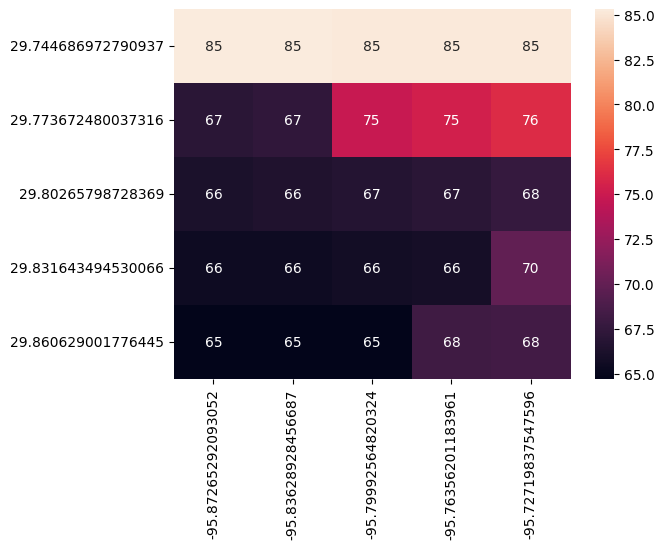

In [25]:
%pip install seaborn
import seaborn as sns
sns.heatmap(df_wind, annot=True)


In [27]:
#46.40143657746181, -124.04022382151945
#45.824471449176094, -123.95105034715706
#44.74598097377521, -124.02323839656866
#42.93922188314332, -124.39267134971814
#41.15782423562303, -124.04871652115708
#39.58413448852998, -123.74818199733545
coordinates = [
    (46.40143657746181, -124.04022382151945),
    (45.824471449176094, -123.95105034715706),
    (44.74598097377521, -124.02323839656866),
    (42.93922188314332, -124.39267134971814),
    (41.15782423562303, -124.04871652115708),
    (39.58413448852998, -123.74818199733545)
]

In [29]:
wind_speeds = []
for coord in coordinates:
    wind_speeds.append(get_wind_speed(coord[0], coord[1]))


Getting data for:46.40143657746181,-124.04022382151945
Getting data for:45.824471449176094,-123.95105034715706
Getting data for:44.74598097377521,-124.02323839656866
Getting data for:42.93922188314332,-124.39267134971814
Getting data for:41.15782423562303,-124.04871652115708
Getting data for:39.58413448852998,-123.74818199733545
[59.4, 49.2, 77.1, 69.0, 68.1, 40.0]


,latitude,longitude
0,46.401437,-124.040224
1,45.824471,-123.951050
2,44.745981,-124.023238
3,42.939222,-124.392671
4,41.157824,-124.048717
5,39.584134,-123.748182


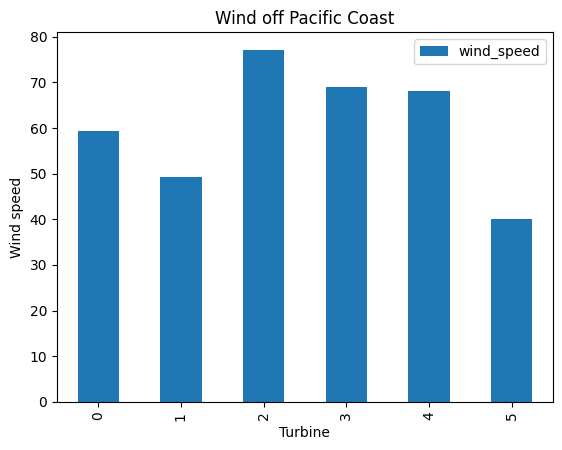

In [38]:
import matplotlib
wind_data = pd.DataFrame(
    coordinates, 
    columns=['latitude', 'longitude'], 
    index=range(len(wind_speeds))
)

wind_speeds_df = pd.DataFrame(wind_speeds, columns=['wind_speed'])
wind_speeds_df.plot(kind='bar', title='Wind off Pacific Coast', xlabel='Turbine', ylabel='Wind speed')

wind_data

